# EDA: 1-Ply Minimax — v15 / v16 / v17

This notebook audits **how one-turn adversarial search actually decides**, then checks
whether those mechanics show up in the round-robin. All three agents inherit
`HeuristicV14` and run the same 1-ply minimax skeleton — **no** `LocalSim` rollouts:

For every legal action of ours (moves **and** allowed switches):
1. Predict the opponent’s remaining moves from the Showdown random-battle set DB
   (fill to 4); if they have a bench, add a hypothetical `"switch"`
2. Score the joint outcome with approximate damage ranges, **speed/priority order**, and
   KO nullification (the slower Pokémon does not act if it faints)
3. Take the **maximin**: pick our action whose *worst-case* score against the
   predicted opponent replies is highest
4. Leaf is risk-averse: \(V = \mathrm{HP}_{me} - 1.5\,\mathrm{HP}_{opp} + \cdots\)

They differ in *what the leaf values* and *whether v14 is allowed to bias the maximin*:

| | **v15** (`HeuristicV15Minimax`) | **v16** (`HeuristicV16Minimax`) | **v17** (`HeuristicV17MinimaxHybrid`) |
|---|---|---|---|
| Leaf | HP + matchup after the simulated turn | + setup / hazard / recovery / status **bonuses** | Same as v16 |
| Before search | Guaranteed KO → 1-ply endgame (≤2 mons) | + setup-sweeper stop, status absorb, early U-turn | Same as v16 |
| v14 relationship | Probe *after* search to log `search_diff` | Same probe | v14 action gets **+0.15** on its worst-case score |
| What “search worked” means | `search_diff_us`: maximin played ≠ v14 | Same | Same, but the prior should make overrides **rarer** |

```
Every turn
──────────
forced faint? ────────── v14 best-switch
guaranteed KO? ───────── take it (no tree)
endgame ≤2 mons? ─────── 1-ply solver
[v16/v17] setup-stop / absorb / early pivot?
                    │
         1-ply minimax (analytic, not simulated)
         for each of our actions a:
           for each predicted opp reply b:
             speed-aware damage  →  V(a,b) = HP_me − 1.5 HP_opp + bonuses
           score(a) = min_b V(a,b)     [+ 0.15 if a is v14’s pick, v17]
         play argmax_a score(a)
         [loop guard if switched last turn]
         log search_diff vs a fresh v14 probe
```

This is the **horizon-effect control** for MCTS: same teacher (v14), same KO
short-circuit, but only **one** future turn and a perfect-information assumption
about the opponent’s replies. If 1-ply already fails to value setup, 5-ply greedy
rollouts are not starting from a solved leaf.

**Sample size.** 10,000 games per matchup except **1,000** vs v18/v19/v20. Each
agent has 253,000 games as *us*. Wilson interval ≈ **±0.19 pp** overall, **±0.98 pp**
on a 10k cell, **±3.1 pp** on an MCTS cell.

Benchmark: `data/benchmarks/all_10k/gen9randombattle`.


In [1]:
# Setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data/benchmarks/all_10k/gen9randombattle").exists():
    ROOT = ROOT.parent
BENCHMARK_DIR = ROOT / "data/benchmarks/all_10k/gen9randombattle"
OUTPUT_DIR = ROOT / "src/p00_core/reporting/agents/minimax_v15_v17"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AGENTS = ["v15", "v16", "v17"]
AGENT_LABEL = {
    "v15": "v15 maximin (HP leaf)",
    "v16": "v16 maximin (positional bonuses)",
    "v17": "v17 hybrid (v14 prior +0.15)",
}
AGENT_COLOR = {"v15": "#B03A2E", "v16": "#1A7A6D", "v17": "#3D5A80"}

PARADIGM_MAP = {
    "random": "Baseline",
    "max_power": "Baseline",
    "abyssal": "Baseline",
    "one_step": "Baseline",
    "safe_one_step": "Baseline",
    "simple_heuristic": "Baseline",
    **{f"v{i}": "Heuristic" for i in range(1, 15)},
    "v15": "Minimax",
    "v16": "Minimax",
    "v17": "Minimax",
    "v18": "MCTS",
    "v19": "MCTS",
    "v20": "MCTS",
    "v21": "IL Hybrid",
    "v22": "IL Pure",
}
PARADIGM_ORDER = ["Baseline", "Heuristic", "Minimax", "MCTS", "IL Hybrid", "IL Pure"]

SEARCH_COLS = [
    "search_moves_us", "search_switches_us", "search_diff_us",
    "endgame_solves_us", "ko_checks_us", "loop_guards_us", "total_turns_us",
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (11, 5.5), "font.size": 11, "savefig.dpi": 160})


def wilson_ci(wins: float, n: float, z: float = 1.96) -> float:
    """Half-width of a 95% Wilson interval, in percentage points."""
    if n <= 0:
        return 0.0
    p = wins / n
    denom = 1.0 + z * z / n
    margin = z * np.sqrt((p * (1 - p) + z * z / (4 * n)) / n) / denom
    return float(margin * 100)


print(f"Root        : {ROOT}")
print(f"Benchmark   : {BENCHMARK_DIR}")
print(f"Export      : {OUTPUT_DIR}")
print(f"Agents      : {AGENTS}")
print("Search      : 1-ply maximin, analytic damage, opp damage × 1.5")
print("v17 prior   : +0.15 on v14's recommended action")


Root        : /home/sirp/Documents/MUDS/TFM_Pokemon
Benchmark   : /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
Export      : /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/minimax_v15_v17
Agents      : ['v15', 'v16', 'v17']
Search      : 1-ply maximin, analytic damage, opp damage × 1.5
v17 prior   : +0.15 on v14's recommended action


## 1 · Load all three agents as *us*

Each row is one finished battle. Search telemetry is written by the worker from the
agent's per-battle counters. `search_diff_us` is a 1-ply disagreement with a fresh
v14 probe — the empirical definition of “minimax overrode the expert”.


In [2]:
# Load v15 / v16 / v17 as player
INT_FILL = [
    "won", "turns", "decisions_us", "fallback_moves_us", "error_moves_us",
    "fainted_us", "remaining_pokemon_us", "fainted_opp", "remaining_pokemon_opp",
    "voluntary_switches_us", "forced_switches_us",
    "supereffective_us", "hazard_sets_us", "setup_uses_us", "ko_checks_us",
    "terastallized_us", "loop_guards_us", *SEARCH_COLS,
]


def load_agent(agent: str) -> pd.DataFrame:
    files = sorted(BENCHMARK_DIR.glob(f"{agent}_vs_*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs for {agent} in {BENCHMARK_DIR}")
    parts = []
    for path in files:
        df = pd.read_csv(path)
        df["agent"] = agent
        df["matchup_opponent"] = df["opponent"]
        parts.append(df)
    out = pd.concat(parts, ignore_index=True)
    for col in INT_FILL:
        if col not in out.columns:
            out[col] = 0
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0)
    out["won_bool"] = out["won"].astype(int)
    out["opponent_paradigm"] = out["matchup_opponent"].map(lambda x: PARADIGM_MAP.get(x, "Other"))
    out["search_decisions"] = out["search_moves_us"] + out["search_switches_us"]
    turns = out["total_turns_us"].replace(0, np.nan)
    out["search_fire_rate"] = out["search_decisions"] / turns
    out["search_diff_rate"] = out["search_diff_us"] / turns
    out["override_of_search"] = out["search_diff_us"] / out["search_decisions"].replace(0, np.nan)
    out["search_switch_share"] = out["search_switches_us"] / out["search_decisions"].replace(0, np.nan)
    return out


frames = {ag: load_agent(ag) for ag in AGENTS}
df = pd.concat(frames.values(), ignore_index=True)

print("Games loaded")
for ag, g in frames.items():
    n_files = g.groupby("matchup_opponent").ngroups
    n_per = g.groupby("matchup_opponent").size()
    print(f"  {ag}: {len(g):>8,} games  |  {n_files} opponents  "
          f"|  median n={int(n_per.median())}  |  WR {g['won_bool'].mean()*100:.2f}%")
print(f"  total: {len(df):,} rows  |  columns {df.shape[1]}")


Games loaded
  v15:  253,000 games  |  28 opponents  |  median n=10000  |  WR 53.80%
  v16:  253,000 games  |  28 opponents  |  median n=10000  |  WR 54.30%
  v17:  253,000 games  |  28 opponents  |  median n=10000  |  WR 57.89%
  total: 759,000 rows  |  columns 79


## 2 · Headline: same 1-ply tree, three leaves / priors

If putting setup/hazard bonuses in the leaf (v16) or adding a v14 prior (v17) did not
matter, win rate, `search_diff`, and setup counts would line up. The interesting
comparisons are **v15 vs v16** (does a positional leaf fix the horizon effect?) and
**v16 vs v17** (does a +0.15 bias toward v14 help, like PUCT did for MCTS?).


In [3]:
# Headline table
rows = []
for ag, g in frames.items():
    n = len(g)
    wins = int(g["won_bool"].sum())
    rows.append({
        "agent": AGENT_LABEL[ag],
        "games": n,
        "win_rate_%": 100 * wins / n,
        "ci95_pp": wilson_ci(wins, n),
        "avg_turns": g["turns"].mean(),
        "avg_hp_us": g["remaining_pokemon_us"].mean(),
        "search_fire_%_turns": 100 * g["search_fire_rate"].mean(),
        "search_moves / game": g["search_moves_us"].mean(),
        "search_switches / game": g["search_switches_us"].mean(),
        "search_diff / game": g["search_diff_us"].mean(),
        "override_%_of_search": 100 * g["override_of_search"].mean(),
        "ko_checks / game": g["ko_checks_us"].mean(),
        "endgame / game": g["endgame_solves_us"].mean(),
        "loop_guards / game": g["loop_guards_us"].mean(),
        "setup / game": g["setup_uses_us"].mean(),
        "hazards / game": g["hazard_sets_us"].mean(),
        "tera / game": g["terastallized_us"].mean(),
    })

headline = pd.DataFrame(rows).set_index("agent")
headline.to_csv(OUTPUT_DIR / "minimax_headline_comparison.csv")
headline.T


## 3 · Who actually chose the action? KO short-circuit vs 1-ply maximin

A guaranteed KO and the ≤2-mon endgame solver run **before** the matrix. If those
paths fire on most turns, the agent is not doing adversarial search — it is v14’s
damage calculator with a 1-ply backup. `search_fire_rate` is the share of turns that
reached the maximin loop.


Mean counts per game
                      v15    v16    v17
ko_checks_us       14.331 14.333 14.488
search_moves_us     3.474  3.615  3.137
search_switches_us  0.978  0.945  1.052
search_diff_us      2.804  2.944  1.651
endgame_solves_us   0.025  0.026  0.026
loop_guards_us      0.277  0.259  0.336
search_fire_rate    0.176  0.176  0.163

Search fire rate (fraction of turns that reached 1-ply maximin)
  v15: 17.6% of turns   KO checks 14.33/game
  v16: 17.6% of turns   KO checks 14.33/game
  v17: 16.3% of turns   KO checks 14.49/game


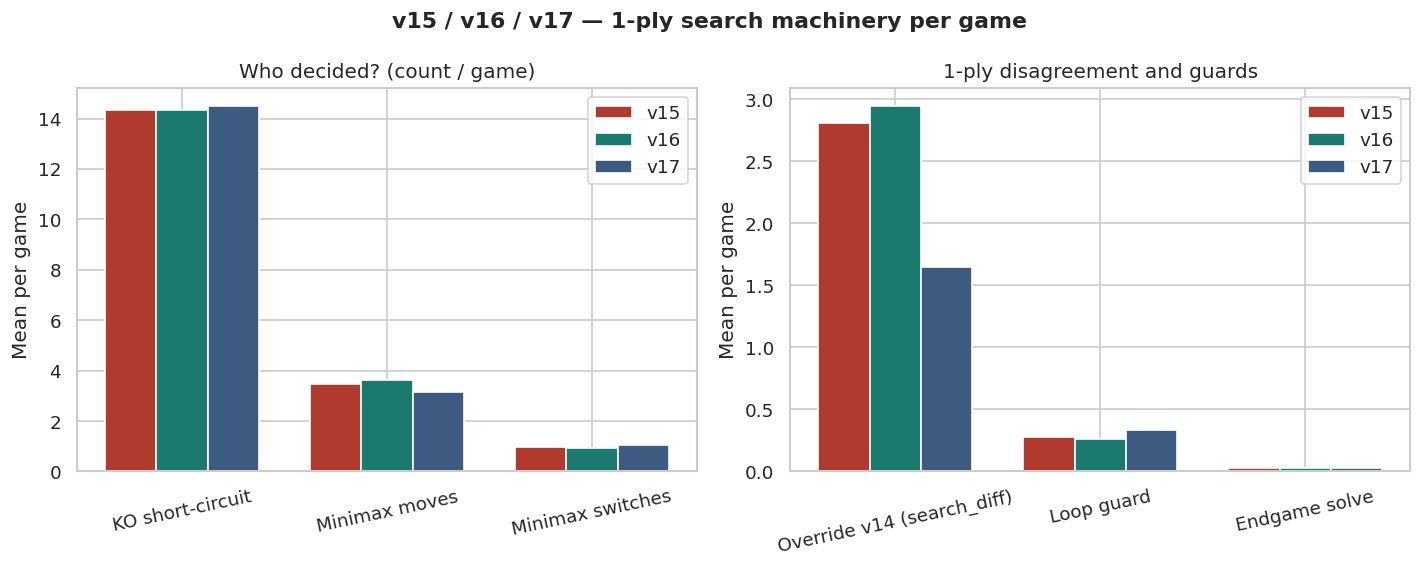

In [4]:
# Decision machinery per game
fp_cols = [
    "ko_checks_us", "search_moves_us", "search_switches_us",
    "search_diff_us", "endgame_solves_us", "loop_guards_us",
]
fp = pd.DataFrame({ag: frames[ag][fp_cols].mean() for ag in AGENTS}).T
fp["search_fire_rate"] = pd.Series({ag: frames[ag]["search_fire_rate"].mean() for ag in AGENTS})
print("Mean counts per game")
print(fp.T.to_string())

print("\nSearch fire rate (fraction of turns that reached 1-ply maximin)")
for ag, g in frames.items():
    print(f"  {ag}: {100*g['search_fire_rate'].mean():.1f}% of turns   "
          f"KO checks {g['ko_checks_us'].mean():.2f}/game")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(3)
w = 0.25
left = ["ko_checks_us", "search_moves_us", "search_switches_us"]
for i, ag in enumerate(AGENTS):
    axes[0].bar(x + (i - 1) * w, [frames[ag][c].mean() for c in left], w,
                color=AGENT_COLOR[ag], label=ag)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["KO short-circuit", "Minimax moves", "Minimax switches"], rotation=12)
axes[0].set_ylabel("Mean per game")
axes[0].set_title("Who decided? (count / game)")
axes[0].legend()

right = ["search_diff_us", "loop_guards_us", "endgame_solves_us"]
for i, ag in enumerate(AGENTS):
    axes[1].bar(x + (i - 1) * w, [frames[ag][c].mean() for c in right], w,
                color=AGENT_COLOR[ag], label=ag)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Override v14 (search_diff)", "Loop guard", "Endgame solve"], rotation=12)
axes[1].set_ylabel("Mean per game")
axes[1].set_title("1-ply disagreement and guards")
axes[1].legend()

fig.suptitle("v15 / v16 / v17 — 1-ply search machinery per game", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_fingerprint_bars.png")
plt.show()


## 4 · When 1-ply search overrides the heuristic (`search_diff`)

`search_diff_us` increments when the maximin action is **not** the action a fresh v14
probe would have played.

- **High override + lower win rate** ⇒ horizon effect: the 1-ply, risk-averse leaf
  (\(1.5	imes\) opponent damage) prefers a safer immediate hit over v14’s delayed
  payoff (setup, rocks, scouting).
- **v16 was supposed to fix that** by putting setup/hazard bonuses in the leaf. If
  override rate and setup counts do not move, the bonuses lost to the \(1.5	imes\)
  term.
- **v17** adds +0.15 to v14’s action. That is a weaker bias than MCTS v20’s PUCT
  prior of 0.70, so overrides should drop, not collapse.

Split `search_diff_rate` by win/loss. If losers overrode more, unconstrained maximin
is hurting.


Override among search decisions, and search_diff/turn in wins vs losses
agent    override%   diff/turn W   diff/turn L   Δ (L−W)
v15           66.5         0.098         0.133    +0.035
v16           67.3         0.099         0.135    +0.036
v17           36.6         0.054         0.076    +0.022


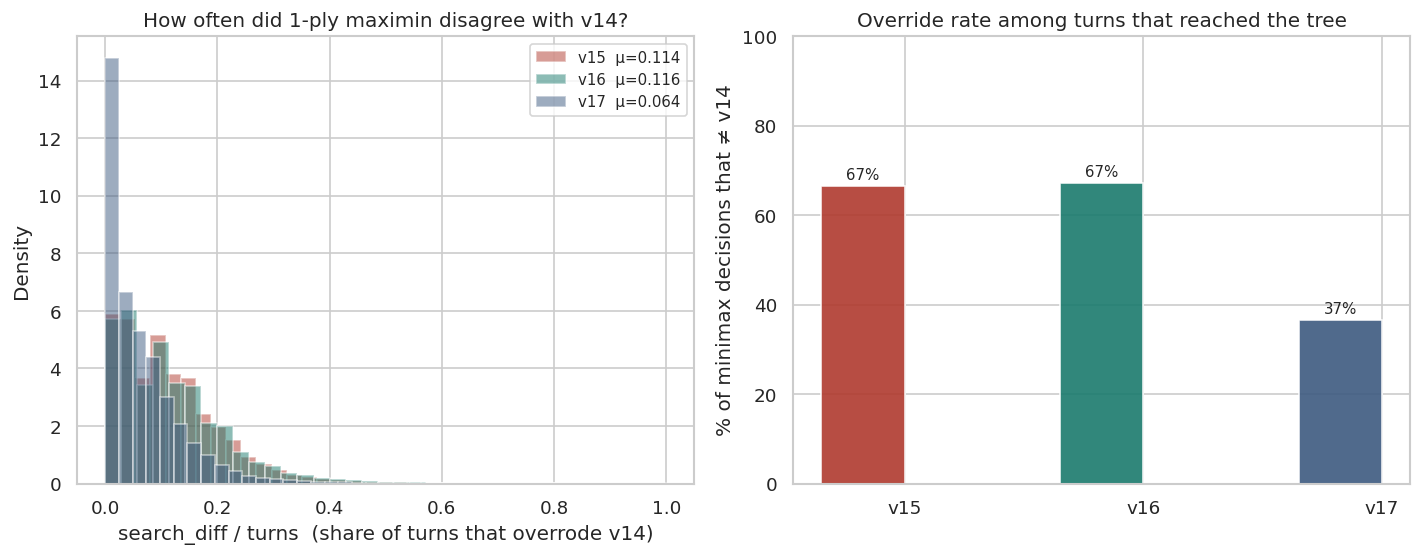

In [5]:
# Override distributions and win/loss split
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ag, g in frames.items():
    vals = g["search_diff_rate"].dropna()
    axes[0].hist(vals, bins=35, density=True, alpha=0.5, color=AGENT_COLOR[ag],
                 label=f"{ag}  μ={vals.mean():.3f}")
axes[0].set_xlabel("search_diff / turns  (share of turns that overrode v14)")
axes[0].set_ylabel("Density")
axes[0].set_title("How often did 1-ply maximin disagree with v14?")
axes[0].legend(fontsize=9)

labels = AGENTS
x = np.arange(len(labels))
w = 0.35
ov = [100 * frames[ag]["override_of_search"].mean() for ag in AGENTS]
axes[1].bar(x - w / 2, ov, w, color=[AGENT_COLOR[ag] for ag in AGENTS], alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("% of minimax decisions that ≠ v14")
axes[1].set_title("Override rate among turns that reached the tree")
axes[1].set_ylim(0, 100)
for i, v in enumerate(ov):
    axes[1].text(i - w / 2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_override.png")
plt.show()

print("Override among search decisions, and search_diff/turn in wins vs losses")
print(f"{'agent':<6}  {'override%':>10}  {'diff/turn W':>12}  {'diff/turn L':>12}  {'Δ (L−W)':>8}")
for ag, g in frames.items():
    wsub = g[g["won_bool"] == 1]["search_diff_rate"].mean()
    lsub = g[g["won_bool"] == 0]["search_diff_rate"].mean()
    print(f"{ag:<6}  {100*g['override_of_search'].mean():10.1f}  "
          f"{wsub:12.3f}  {lsub:12.3f}  {lsub-wsub:+8.3f}")


## 5 · Does 1-ply search value the future? Setup, hazards, Tera

v16’s leaf explicitly bonuses Dragon Dance / Stealth Rock / Recover. If those bonuses
were large enough to survive \(1.5	imes\) opponent damage, `setup_uses_us` and
`hazard_sets_us` would rise toward v9/v12 (~1.6 / ~0.16). If they stay at v14 levels
(~0.22 / ~0.04), **the horizon effect is not fixed by decorating a 1-ply leaf**.


  setup_uses_us             v15=0.207  v16=0.213  v17=0.209
  hazard_sets_us            v15=0.049  v16=0.044  v17=0.043
  terastallized_us          v15=0.396  v16=0.390  v17=0.380
  voluntary_switches_us     v15=1.997  v16=1.964  v17=2.072
  supereffective_us         v15=4.241  v16=4.241  v17=4.394

Reference (heuristic / IL / MCTS notebooks):
  v12 setup ≈ 1.73, hazards ≈ 0.18, tera ≈ 0.95
  v14 setup ≈ 0.22, hazards ≈ 0.03, tera ≈ 0.31
  v18–v20 setup ≈ 0.21, hazards ≈ 0.04  (5-ply greedy rollouts, same ceiling)


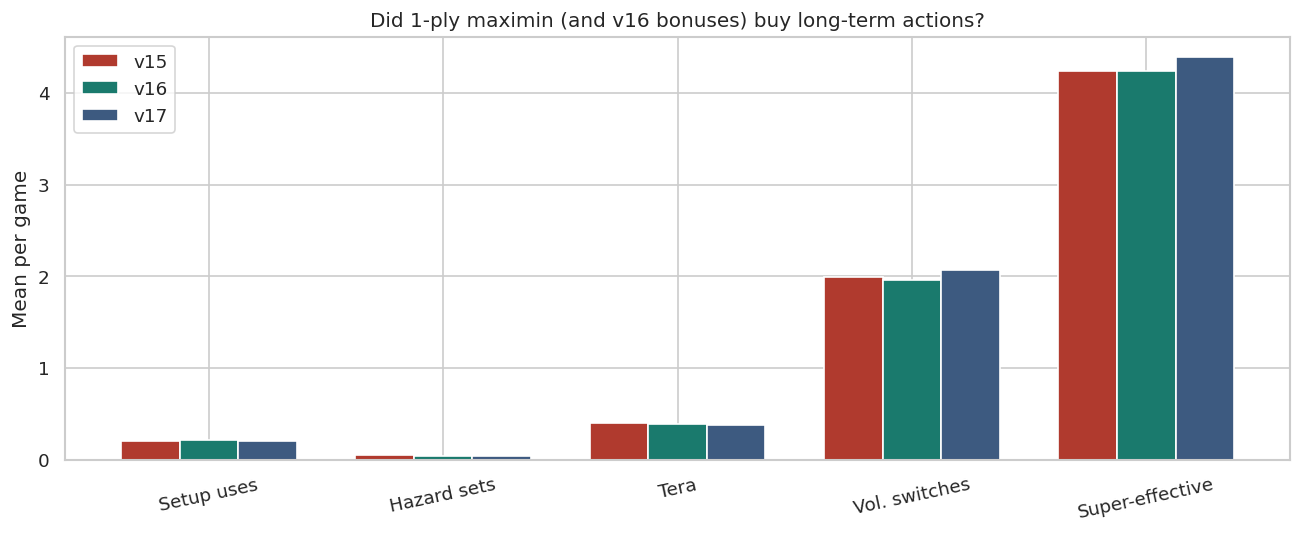

In [6]:
# Future-payoff proxies
proxy = ["setup_uses_us", "hazard_sets_us", "terastallized_us",
         "voluntary_switches_us", "supereffective_us"]
fig, ax = plt.subplots(figsize=(11, 4.6))
idx = np.arange(len(proxy))
w = 0.25
for i, ag in enumerate(AGENTS):
    ax.bar(idx + (i - 1) * w, [frames[ag][c].mean() for c in proxy], w,
           color=AGENT_COLOR[ag], label=ag)
ax.set_xticks(idx)
ax.set_xticklabels(["Setup uses", "Hazard sets", "Tera", "Vol. switches", "Super-effective"],
                   rotation=12)
ax.set_ylabel("Mean per game")
ax.set_title("Did 1-ply maximin (and v16 bonuses) buy long-term actions?")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_future_proxies.png")
plt.show()

for c in proxy:
    vals = "  ".join(f"{ag}={frames[ag][c].mean():.3f}" for ag in AGENTS)
    print(f"  {c:24s}  {vals}")
print("\nReference (heuristic / IL / MCTS notebooks):")
print("  v12 setup ≈ 1.73, hazards ≈ 0.18, tera ≈ 0.95")
print("  v14 setup ≈ 0.22, hazards ≈ 0.03, tera ≈ 0.31")
print("  v18–v20 setup ≈ 0.21, hazards ≈ 0.04  (5-ply greedy rollouts, same ceiling)")


## 6 · Win rate across the same opponents

Grouped bars. MCTS cells (v18–v20) are 1,000 games (~±3 pp); everything else is 10,000
(~±1 pp). Discriminating opponents: **v12 / v13 / v14** and **Abyssal**.


v16 vs v15 mean Δ: +0.70 pp  (ahead in 23 / 28)
v17 vs v15 mean Δ: +4.22 pp  (ahead in 27 / 28)

Largest hybrid gains (v17 − v15):
matchup_opponent
v20                10.700
simple_heuristic    5.520
v9                  5.500
v7                  5.230
safe_one_step       5.080
abyssal             5.070

Smallest v17 − v15 gaps:
matchup_opponent
random      -0.020
max_power    1.200
v22          1.600
v19          2.000
v13          2.280
one_step     3.040


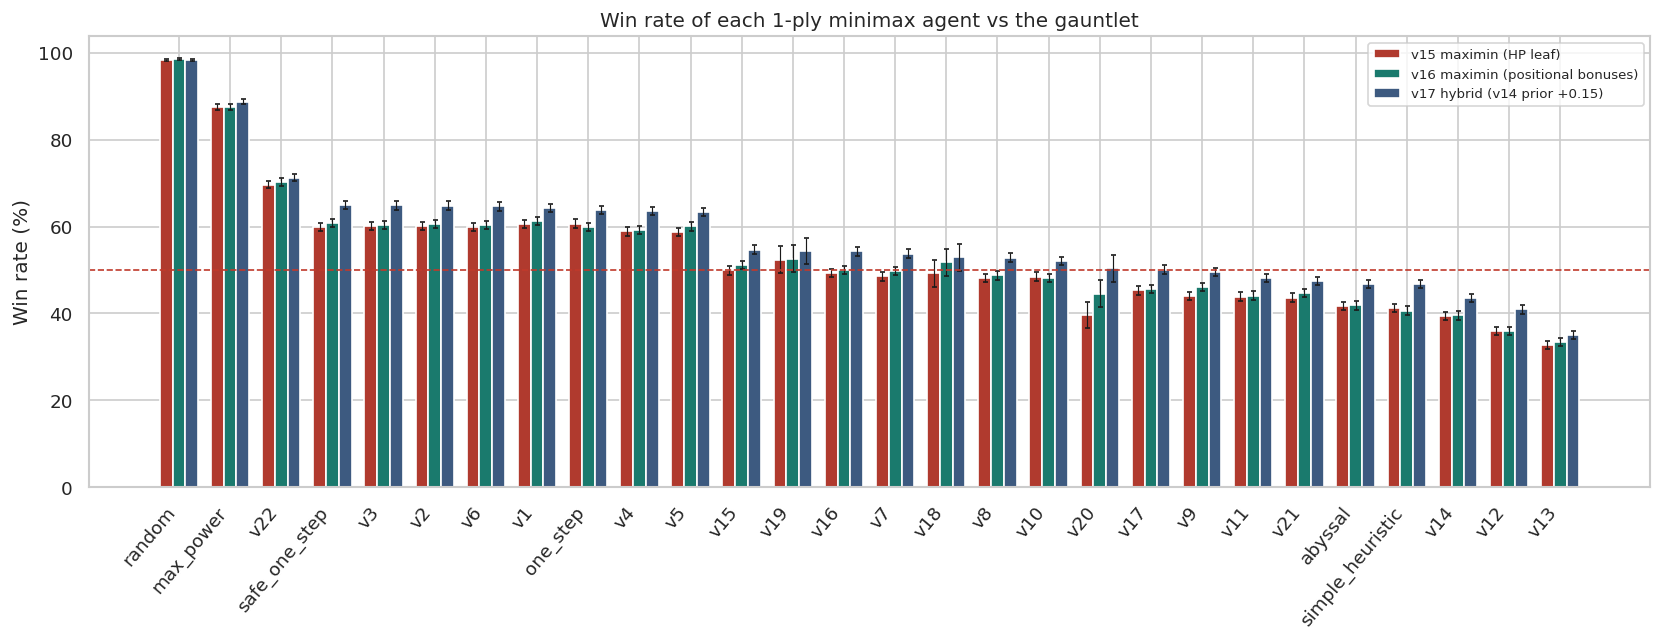

In [7]:
# Per-opponent win rates
def wr_table(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("matchup_opponent").agg(games=("won_bool", "size"), wins=("won_bool", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    t["paradigm"] = t.index.map(lambda x: PARADIGM_MAP.get(x, "Other"))
    return t


wr = {ag: wr_table(g) for ag, g in frames.items()}
cmp = wr["v15"].add_prefix("v15_")
for ag in ("v16", "v17"):
    cmp = cmp.join(wr[ag].add_prefix(f"{ag}_"), how="outer")
cmp["delta_v17_v15"] = cmp["v17_win_rate"] - cmp["v15_win_rate"]
cmp["delta_v16_v15"] = cmp["v16_win_rate"] - cmp["v15_win_rate"]
cmp = cmp.sort_values("v17_win_rate", ascending=False)
cmp.to_csv(OUTPUT_DIR / "minimax_winrate_by_opponent.csv")

order = list(cmp.index)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(14, 5.5))
w = 0.25
for i, ag in enumerate(AGENTS):
    ax.bar(x + (i - 1) * w, cmp.loc[order, f"{ag}_win_rate"], w,
           yerr=cmp.loc[order, f"{ag}_ci95"], capsize=1.5,
           color=AGENT_COLOR[ag], label=AGENT_LABEL[ag], error_kw={"elinewidth": 0.7})
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=50, ha="right")
ax.set_ylabel("Win rate (%)")
ax.set_title("Win rate of each 1-ply minimax agent vs the gauntlet")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_winrate_grouped.png")
plt.show()

print(f"v16 vs v15 mean Δ: {cmp['delta_v16_v15'].mean():+.2f} pp  "
      f"(ahead in {(cmp['delta_v16_v15'] > 0).sum()} / {len(cmp)})")
print(f"v17 vs v15 mean Δ: {cmp['delta_v17_v15'].mean():+.2f} pp  "
      f"(ahead in {(cmp['delta_v17_v15'] > 0).sum()} / {len(cmp)})")
print("\nLargest hybrid gains (v17 − v15):")
print(cmp["delta_v17_v15"].sort_values(ascending=False).head(6).to_string())
print("\nSmallest v17 − v15 gaps:")
print(cmp["delta_v17_v15"].sort_values().head(6).to_string())


## 7 · Head-to-head among the three 1-ply agents

Independent samples, not flipped games. v15 vs v16 tests the leaf bonuses (10k games,
CI ±1 pp). v16 vs v17 tests the +0.15 prior.


In [8]:
# Direct H2H triangle
h2h_rows = []
for a in AGENTS:
    for b in AGENTS:
        if a == b:
            continue
        sub = frames[a][frames[a]["matchup_opponent"] == b]
        n, w = len(sub), int(sub["won_bool"].sum())
        h2h_rows.append({
            "file": f"{a}_vs_{b}",
            "games": n,
            "win_rate_%": 100 * w / n,
            "ci95_pp": wilson_ci(w, n),
            "search_diff / game": sub["search_diff_us"].mean(),
            "override_%": 100 * sub["override_of_search"].mean(),
            "search_fire_%": 100 * sub["search_fire_rate"].mean(),
        })
h2h_df = pd.DataFrame(h2h_rows).set_index("file")
print(h2h_df.to_string())
print()
for a, b in (("v15", "v16"), ("v15", "v17"), ("v16", "v17")):
    s = (h2h_df.loc[f"{a}_vs_{b}", "win_rate_%"] + h2h_df.loc[f"{b}_vs_{a}", "win_rate_%"]) / 100
    print(f"  WR({a} vs {b}) + WR({b} vs {a}) = {s:.4f}")


            games  win_rate_%  ci95_pp  search_diff / game  override_%  search_fire_%
file                                                                                 
v15_vs_v16  10000      49.280    0.980               2.977      64.390         18.168
v15_vs_v17  10000      45.340    0.976               2.952      64.320         18.464
v16_vs_v15  10000      51.140    0.980               3.137      65.825         18.135
v16_vs_v17  10000      45.680    0.976               3.182      64.973         18.610
v17_vs_v15  10000      54.710    0.975               1.816      38.047         17.065
v17_vs_v16  10000      54.300    0.976               1.893      37.687         17.237

  WR(v15 vs v16) + WR(v16 vs v15) = 1.0042
  WR(v15 vs v17) + WR(v17 vs v15) = 1.0005
  WR(v16 vs v17) + WR(v17 vs v16) = 0.9998


## 8 · Strength by opponent paradigm

Does 1-ply maximin help against knowledge-heavy heuristics, against 5-ply MCTS, or
only against weak baselines?


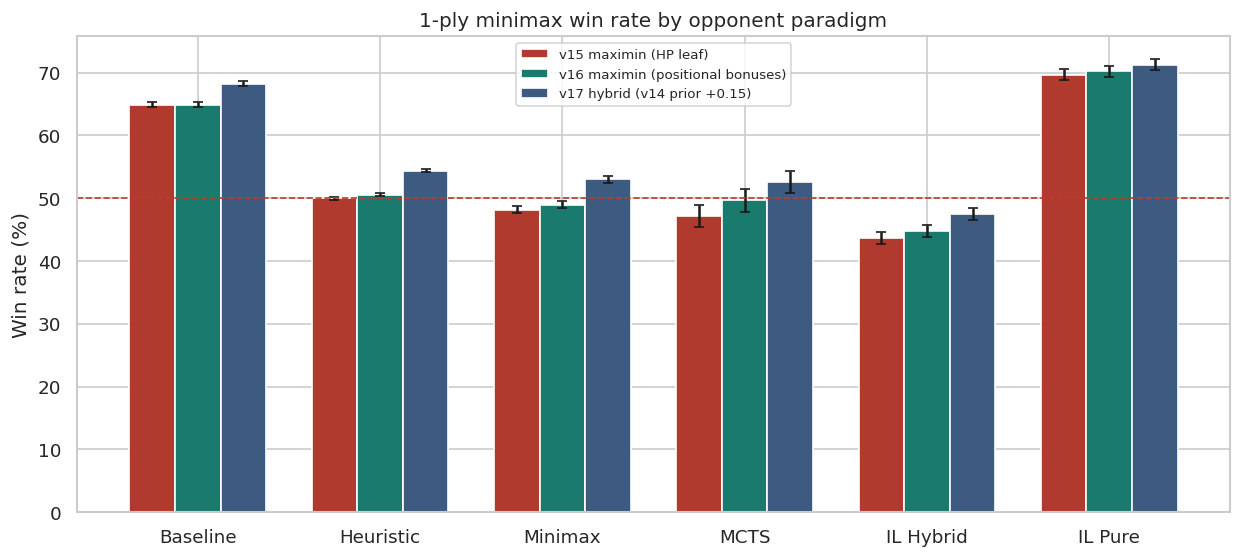

In [9]:
# Paradigm-level WR
def paradigm_wr(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("opponent_paradigm").agg(games=("won_bool", "size"), wins=("won_bool", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    return t.reindex([p for p in PARADIGM_ORDER if p in t.index])


pw = {ag: paradigm_wr(g) for ag, g in frames.items()}
labels = list(pw["v15"].index)
x = np.arange(len(labels))
w = 0.25
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for i, ag in enumerate(AGENTS):
    ax.bar(x + (i - 1) * w, pw[ag]["win_rate"], w, yerr=pw[ag]["ci95"],
           capsize=3, color=AGENT_COLOR[ag], label=AGENT_LABEL[ag])
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Win rate (%)")
ax.set_title("1-ply minimax win rate by opponent paradigm")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_wr_by_paradigm.png")
plt.show()

joined = pw["v15"].add_prefix("v15_")
for ag in ("v16", "v17"):
    joined = joined.join(pw[ag].add_prefix(f"{ag}_"))
joined


## 9 · Discriminating matchups: v12, v14, Abyssal, v20, v21

v12 is the bot-vs-bot knowledge ceiling. v14 is the teacher inside every minimax
agent. v20 is 5-ply PUCT — the natural “deeper search” sibling. If 1-ply beat its
teacher, v17 vs v14 would sit clearly above 50% at n = 10,000.


                   paradigm  v15_wr  v15_ci  v15_n  v16_wr  v16_ci  v16_n  v17_wr  v17_ci  v17_n
opponent                                                                                        
v12               Heuristic  36.040   0.941  10000  35.920   0.940  10000  40.940   0.964  10000
v13               Heuristic  32.820   0.920  10000  33.500   0.925  10000  35.100   0.935  10000
v14               Heuristic  39.430   0.958  10000  39.560   0.958  10000  43.610   0.972  10000
abyssal            Baseline  41.720   0.966  10000  41.860   0.967  10000  46.790   0.978  10000
simple_heuristic   Baseline  41.230   0.965  10000  40.650   0.963  10000  46.750   0.978  10000
v18                    MCTS  49.300   3.093   1000  51.800   3.091   1000  52.900   3.088   1000
v20                    MCTS  39.700   3.027   1000  44.600   3.075   1000  50.400   3.093   1000
v21               IL Hybrid  43.650   0.972  10000  44.750   0.974  10000  47.500   0.979  10000
v22                 IL Pure  6

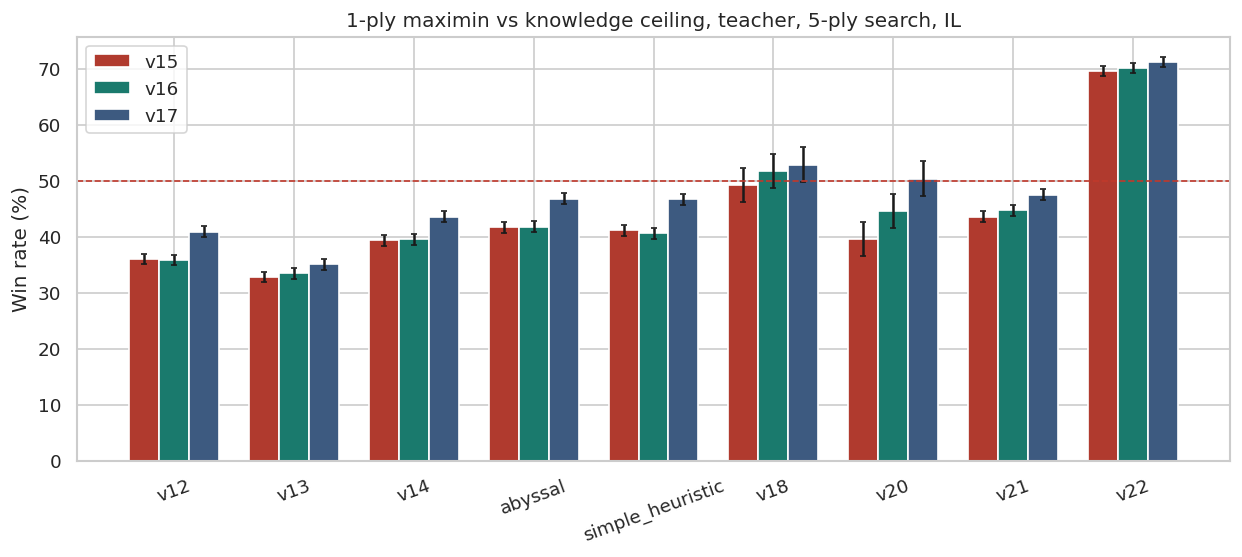

In [10]:
# Key matchup table
keys = ["v12", "v13", "v14", "abyssal", "simple_heuristic", "v18", "v20", "v21", "v22"]
rows = []
for opp in keys:
    rec = {"opponent": opp, "paradigm": PARADIGM_MAP.get(opp, "?")}
    for ag in AGENTS:
        if opp not in wr[ag].index:
            rec[f"{ag}_wr"] = np.nan
            rec[f"{ag}_ci"] = np.nan
            rec[f"{ag}_n"] = 0
            continue
        sub = wr[ag].loc[opp]
        rec[f"{ag}_wr"] = float(sub["win_rate"])
        rec[f"{ag}_ci"] = float(sub["ci95"])
        rec[f"{ag}_n"] = int(sub["games"])
    rows.append(rec)
key_df = pd.DataFrame(rows).set_index("opponent")
print(key_df.to_string())

fig, ax = plt.subplots(figsize=(10.5, 4.8))
idx = np.arange(len(keys))
w = 0.25
for i, ag in enumerate(AGENTS):
    ax.bar(idx + (i - 1) * w, [key_df.loc[k, f"{ag}_wr"] for k in keys], w,
           yerr=[key_df.loc[k, f"{ag}_ci"] for k in keys], capsize=2,
           color=AGENT_COLOR[ag], label=ag)
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(idx)
ax.set_xticklabels(keys, rotation=20)
ax.set_ylabel("Win rate (%)")
ax.set_title("1-ply maximin vs knowledge ceiling, teacher, 5-ply search, IL")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_key_matchups.png")
plt.show()


## 10 · Switching that came from the maximin

Risk-averse 1-ply (\(1.5	imes\) incoming damage) should switch more than a greedy
heuristic when the active Pokémon is about to be punished. `search_switches_us` is
switches the matrix actually picked.


Means
  voluntary_switches_us       v15=1.997  v16=1.964  v17=2.072
  search_switches_us          v15=0.978  v16=0.945  v17=1.052
  search_switch_share         v15=0.291  v16=0.285  v17=0.364
  loop_guards_us              v15=0.277  v16=0.259  v17=0.336


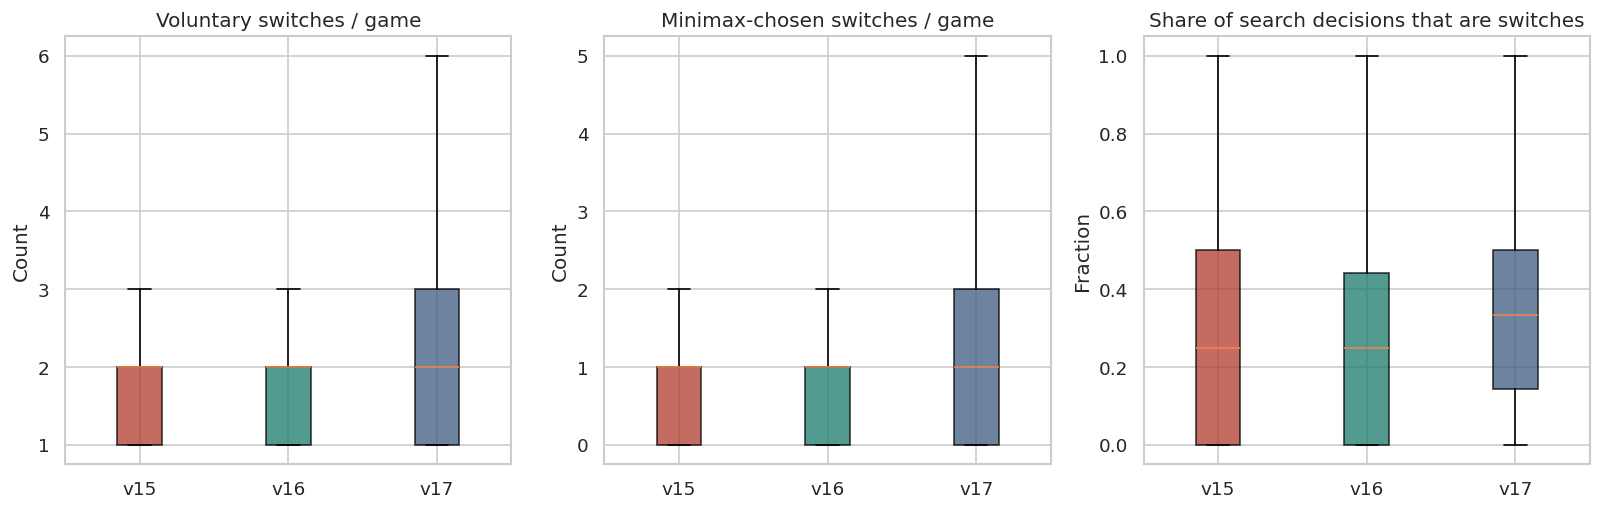

In [11]:
# Switching from search
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, col, title in [
    (axes[0], "voluntary_switches_us", "Voluntary switches / game"),
    (axes[1], "search_switches_us", "Minimax-chosen switches / game"),
    (axes[2], "search_switch_share", "Share of search decisions that are switches"),
]:
    data = [frames[ag][col].dropna() for ag in AGENTS]
    bp = ax.boxplot(data, tick_labels=AGENTS, patch_artist=True, showfliers=False)
    for patch, ag in zip(bp["boxes"], AGENTS):
        patch.set_facecolor(AGENT_COLOR[ag])
        patch.set_alpha(0.75)
    ax.set_title(title)
    ax.set_ylabel("Fraction" if col == "search_switch_share" else "Count")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_switching_box.png")
plt.show()

print("Means")
for col in ["voluntary_switches_us", "search_switches_us", "search_switch_share", "loop_guards_us"]:
    vals = "  ".join(f"{ag}={frames[ag][col].mean():.3f}" for ag in AGENTS)
    print(f"  {col:26s}  {vals}")


## 11 · Game length and leftover HP

A risk-averse maximin that over-switches should leave more HP or play longer. The
hybrid that hugs v14 should look like v14.


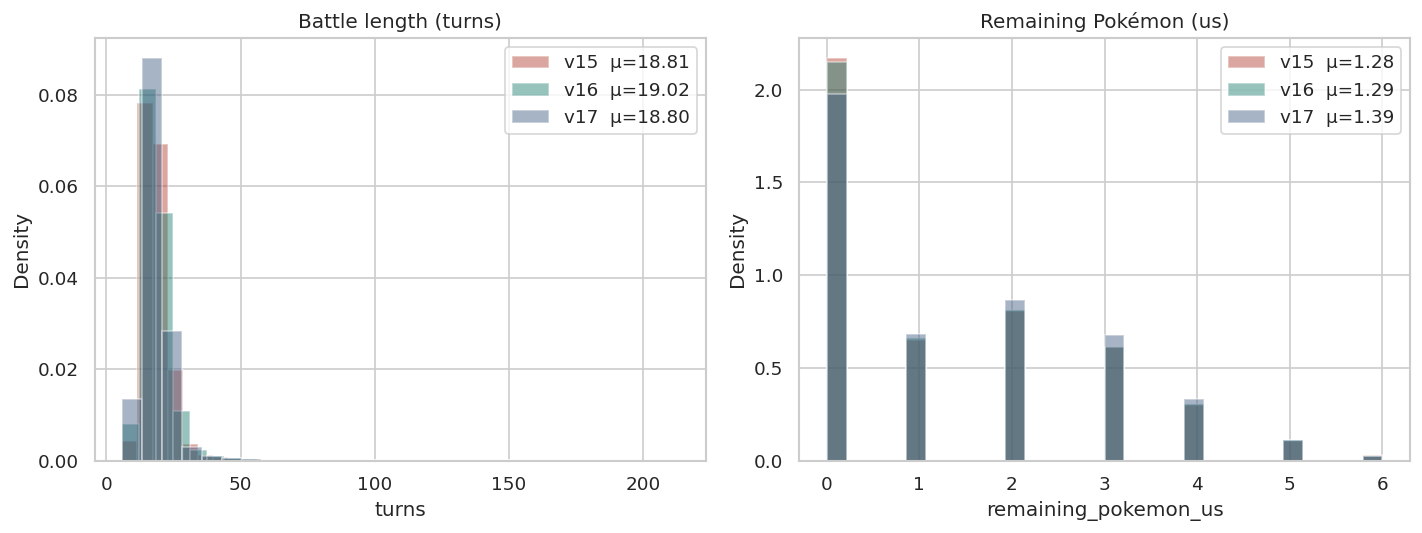

In [12]:
# Duration and leftover HP
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, col, title in [
    (axes[0], "turns", "Battle length (turns)"),
    (axes[1], "remaining_pokemon_us", "Remaining Pokémon (us)"),
]:
    for ag, g in frames.items():
        ax.hist(g[col], bins=28, density=True, alpha=0.45, color=AGENT_COLOR[ag],
                label=f"{ag}  μ={g[col].mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "minimax_length_hp.png")
plt.show()


## 12 · Self-play sanity

Each agent vs itself should sit near 50% (n = 10,000 ⇒ ±0.98 pp).


In [13]:
# Self-play
for ag, g in frames.items():
    sub = g[g["matchup_opponent"] == ag]
    n, w = len(sub), int(sub["won_bool"].sum())
    print(f"  {ag} vs {ag}:  {100*w/n:.2f}%  ±{wilson_ci(w, n):.2f}  (n={n:,})")


  v15 vs v15:  49.92%  ±0.98  (n=10,000)
  v16 vs v16:  49.97%  ±0.98  (n=10,000)
  v17 vs v17:  50.12%  ±0.98  (n=10,000)


## 13 · Export comparison report


In [14]:
# Markdown report
lines = [
    "# 1-Ply Minimax EDA — v15 / v16 / v17",
    "",
    "Deep thesis write-up: [`../../heuristics_and_imitation_thesis_analysis.md`](../../heuristics_and_imitation_thesis_analysis.md).",
    "",
    "Source: `data/benchmarks/all_10k/gen9randombattle` (each agent as us vs 28 opponents;",
    "10k games, or 1k vs v18/v19/v20).",
    "Search: analytic 1-ply maximin, approximate damage ranges, opponent damage × 1.5.",
    "",
    "## Architecture in one paragraph",
    "",
    "All three agents are 1-ply adversarial search on top of HeuristicV14. For each legal",
    "action they evaluate the worst-case reply among predicted opponent moves (set DB) and",
    "a hypothetical switch, resolving speed/priority and KOs analytically — no LocalSim.",
    "**v15** uses an HP/matchup leaf. **v16** adds setup/hazard/recovery/status bonuses and",
    "v14 tactical overrides before the matrix. **v17** is v16 plus +0.15 on v14’s action.",
    "",
    "## Headline",
    "",
    headline.to_markdown(),
    "",
    "## 1-ply vs the heuristic",
    "",
    "- Search only runs on **~16–18% of turns**; the rest are guaranteed-KO short-circuits",
    "  (~14 KO checks / game). One-ply maximin is a backup, not the default policy.",
    "- Of the turns that *do* reach the matrix, **v15/v16 override v14 on ~67%** of",
    "  decisions. Losers override more than winners (search_diff/turn 0.13 vs 0.10).",
    "- **v16’s positional leaf does not help**: overall +0.5 pp vs v15, H2H ~50%, setup",
    "  uses stay at 0.21 (v14-like, not v12-like). The 1.5× opponent-damage term dominates",
    "  the 0.25–0.35 setup/hazard bonuses.",
    "- **v17 overrides on 37%** of search decisions (prior +0.15) and is the strongest",
    "  1-ply agent (overall +4.1 pp vs v15). Still below v12 (40.9% vs v12) and below",
    "  its teacher (43.6% vs v14).",
    "",
    "## Head-to-head",
    "",
    h2h_df.to_markdown(),
    "",
    "## Discriminating matchups (WR %)",
    "",
    key_df.to_markdown(),
    "",
    "## Paradigm win rates",
    "",
    joined.to_markdown(),
    "",
    "## Figures",
    "",
    "- `minimax_fingerprint_bars.png`",
    "- `minimax_override.png`",
    "- `minimax_future_proxies.png`",
    "- `minimax_winrate_grouped.png`",
    "- `minimax_wr_by_paradigm.png`",
    "- `minimax_key_matchups.png`",
    "- `minimax_switching_box.png`",
    "- `minimax_length_hp.png`",
]

report_path = OUTPUT_DIR / "minimax_v15_v17_comparison.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")
print(f"Plots in {OUTPUT_DIR}")


Wrote /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/minimax_v15_v17/minimax_v15_v17_comparison.md
Plots in /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/minimax_v15_v17
